In [2]:
import pandas as pd

train_transaction = pd.read_csv("../data/raw/train_transaction.csv")
train_identity = pd.read_csv("../data/raw/train_identity.csv")

train = train_transaction.merge(train_identity, on="TransactionID", how="left")

print(train.shape)

(590540, 434)


# Target Analysis


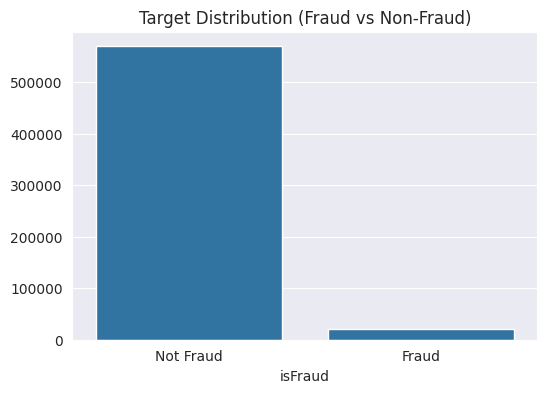

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

target_counts = train["isFraud"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title("Target Distribution (Fraud vs Non-Fraud)")
plt.xticks([0,1], ["Not Fraud", "Fraud"])
plt.show()

print(train["isFraud"].value_counts(normalize=True))

# Missing Values Analysis

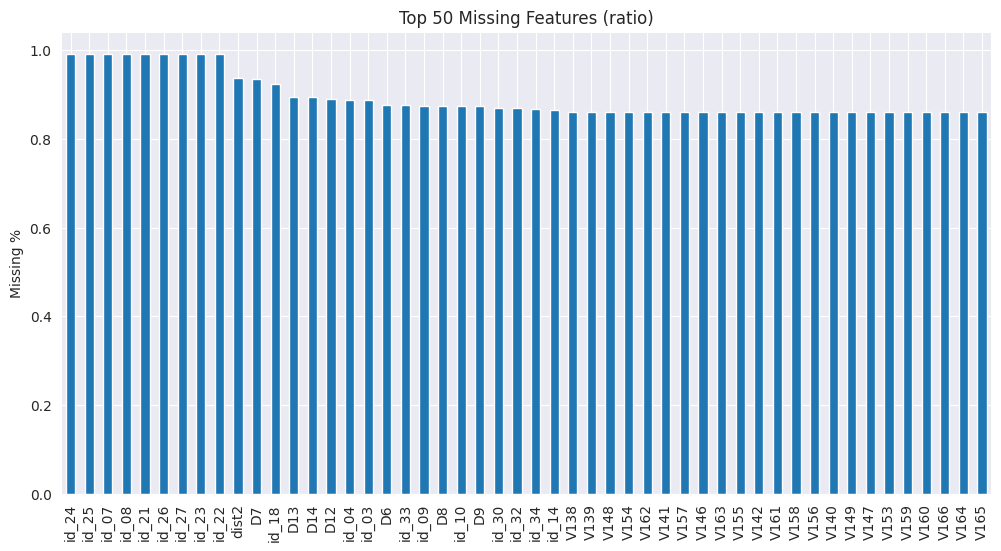

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_04    0.887689
id_03    0.887689
D6       0.876068
id_33    0.875895
id_09    0.873123
dtype: float64


In [4]:
missing_ratio = train.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_ratio.head(50).plot(kind="bar")
plt.title("Top 50 Missing Features (ratio)")
plt.ylabel("Missing %")
plt.show()

print(missing_ratio.head(20))

# Numerical Features Analysis

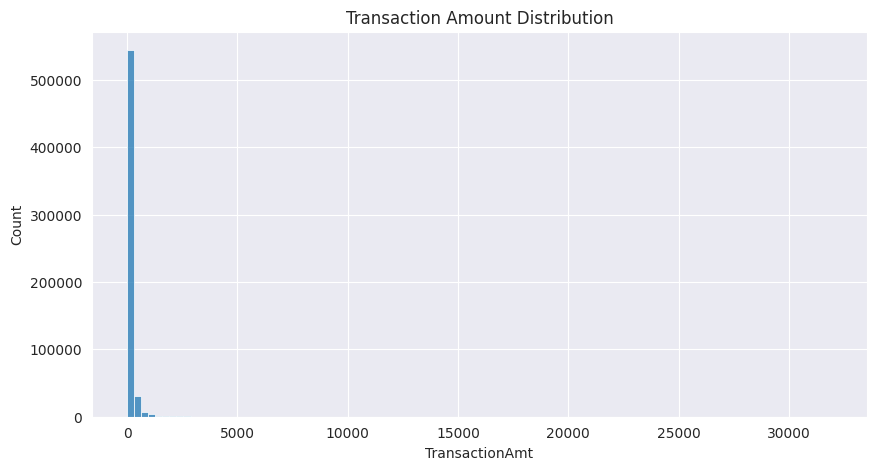

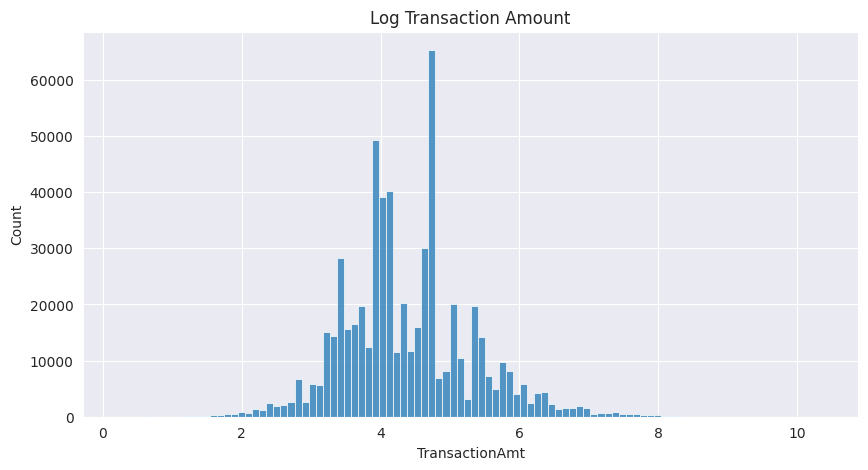

Skew: 14.374489573829827


In [5]:
plt.figure(figsize=(10,5))
sns.histplot(train["TransactionAmt"], bins=100)
plt.title("Transaction Amount Distribution")
plt.show()

# Log transform (better view)
import numpy as np

plt.figure(figsize=(10,5))
sns.histplot(np.log1p(train["TransactionAmt"]), bins=100)
plt.title("Log Transaction Amount")
plt.show()

print("Skew:", train["TransactionAmt"].skew())

# Compare Transaction Amount distribution for Fraud vs Non-Fraud

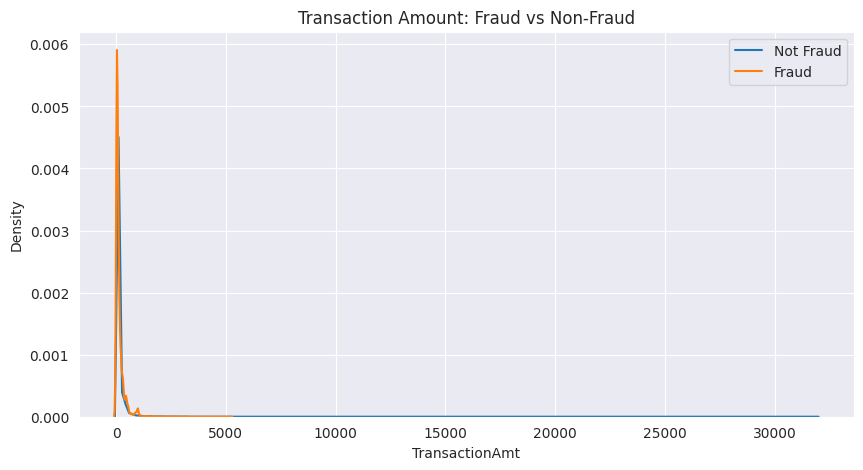

In [6]:
plt.figure(figsize=(10,5))
sns.kdeplot(train.loc[train["isFraud"] == 0, "TransactionAmt"], label="Not Fraud")
sns.kdeplot(train.loc[train["isFraud"] == 1, "TransactionAmt"], label="Fraud")
plt.legend()
plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.show()

# Time based features

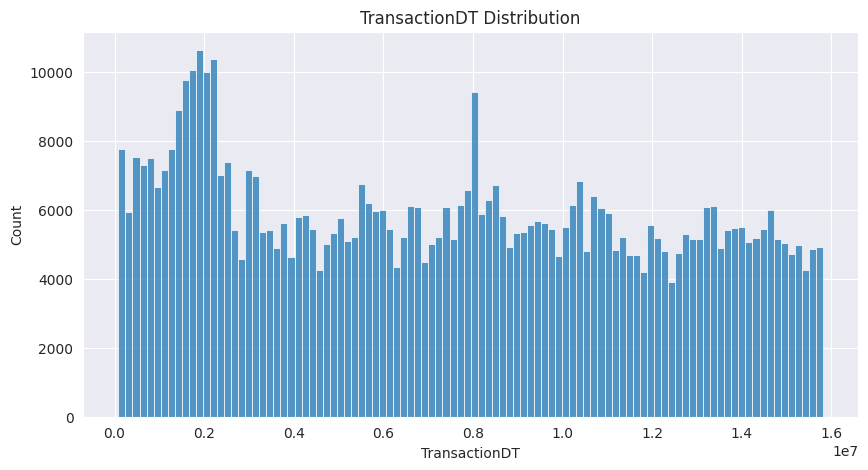

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(train["TransactionDT"], bins=100)
plt.title("TransactionDT Distribution")
plt.show()

# Numerical Features vs Target

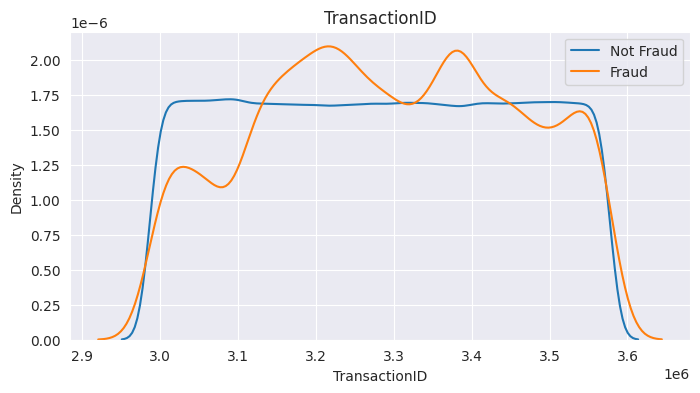

/tmp/ipykernel_4545/2893552762.py:11: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_4545/2893552762.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/tmp/ipykernel_4545/2893552762.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


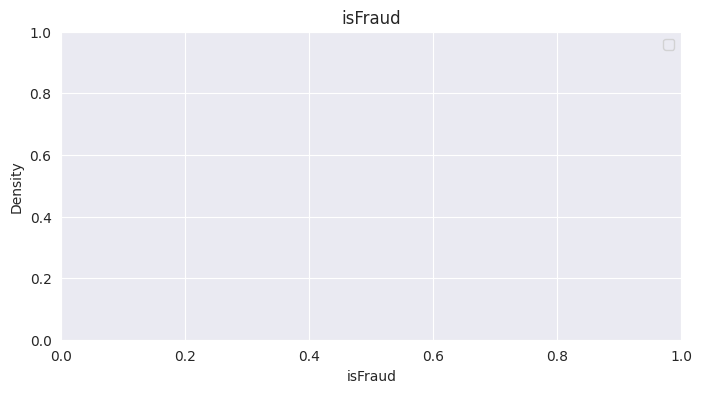

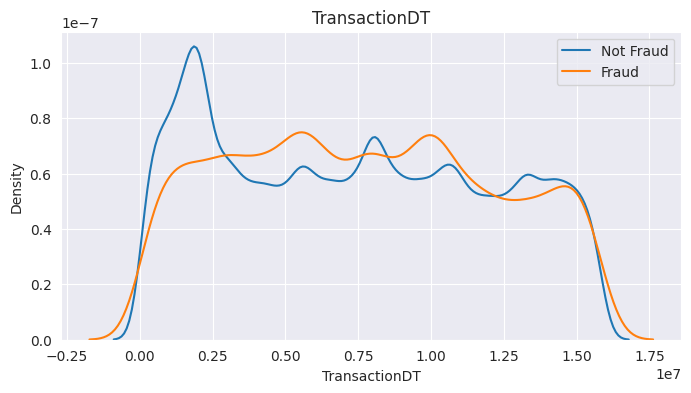

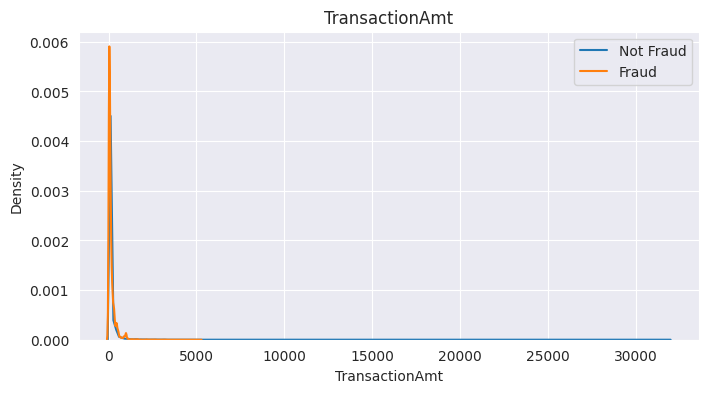

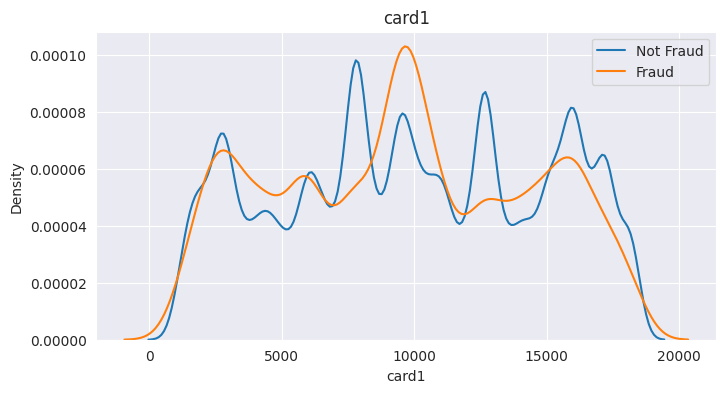

In [15]:
num_cols = train.select_dtypes(include=["int64", "float64"]).columns

sample_cols = num_cols[:5]  # don’t plot 400 features

for col in sample_cols:
    if train[col].nunique() < 2:
        continue

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        train.loc[train["isFraud"] == 0, col].dropna(),
        label="Not Fraud"
    )

    sns.kdeplot(
        train.loc[train["isFraud"] == 1, col].dropna(),
        label="Fraud"
    )

    plt.title(col)
    plt.legend()
    plt.show()

# Categorical Features Analysis

In [17]:
cat_cols = train.select_dtypes(include=["object", "string"]).columns
print(f"Categorical columns: {len(cat_cols)}")

Categorical columns: 31


# Cardinality

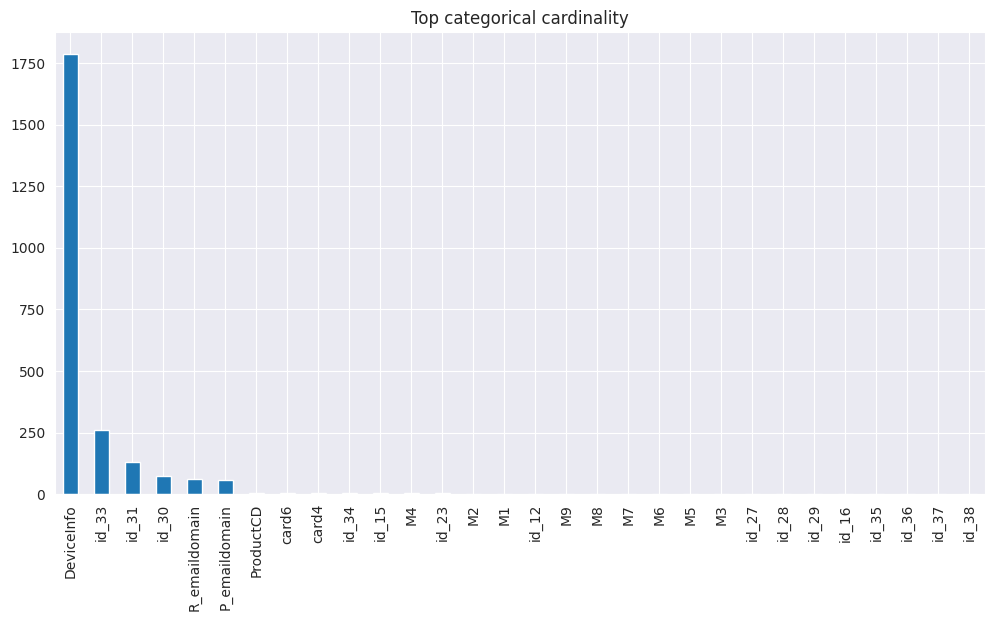

DeviceInfo       1786
id_33             260
id_31             130
id_30              75
R_emaildomain      60
P_emaildomain      59
ProductCD           5
card6               4
card4               4
id_34               4
id_15               3
M4                  3
id_23               3
M2                  2
M1                  2
id_12               2
M9                  2
M8                  2
M7                  2
M6                  2
dtype: int64


In [10]:
cardinality = train[cat_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(12,6))
cardinality.head(30).plot(kind="bar")
plt.title("Top categorical cardinality")
plt.show()

print(cardinality.head(20))

# Near Zero Variance

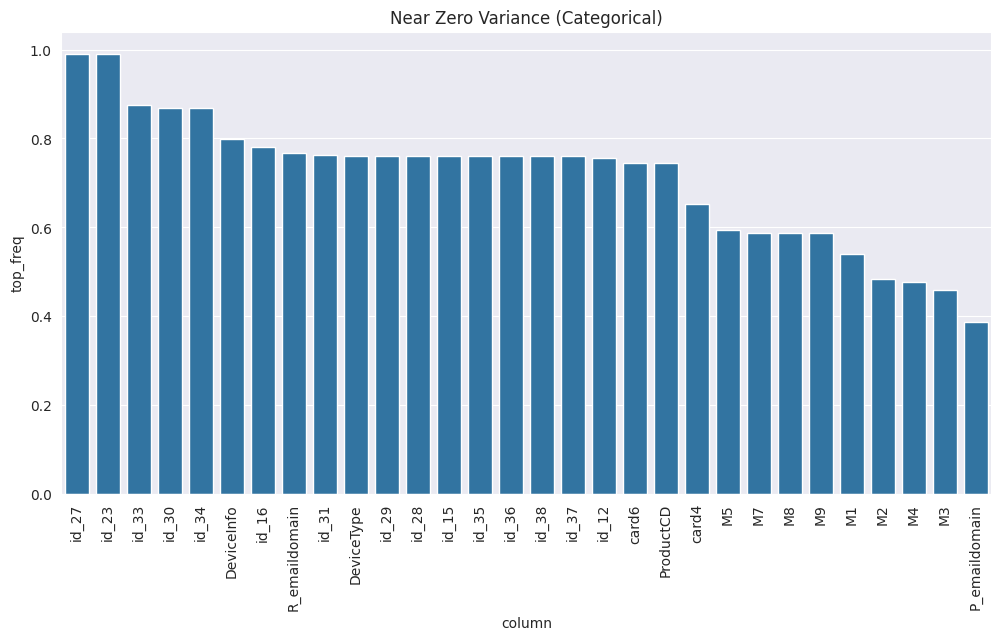

   column  top_freq
18  id_27  0.991247
17  id_23  0.991247


In [11]:
cat_variance = []

for col in cat_cols:
    top_freq = train[col].value_counts(normalize=True, dropna=False).iloc[0]
    cat_variance.append((col, top_freq))

cat_variance_df = pd.DataFrame(cat_variance, columns=["column", "top_freq"])
cat_variance_df = cat_variance_df.sort_values("top_freq", ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x="column", y="top_freq", data=cat_variance_df.head(30))
plt.xticks(rotation=90)
plt.title("Near Zero Variance (Categorical)")
plt.show()

print(cat_variance_df[cat_variance_df["top_freq"] > 0.95])

# Correlation

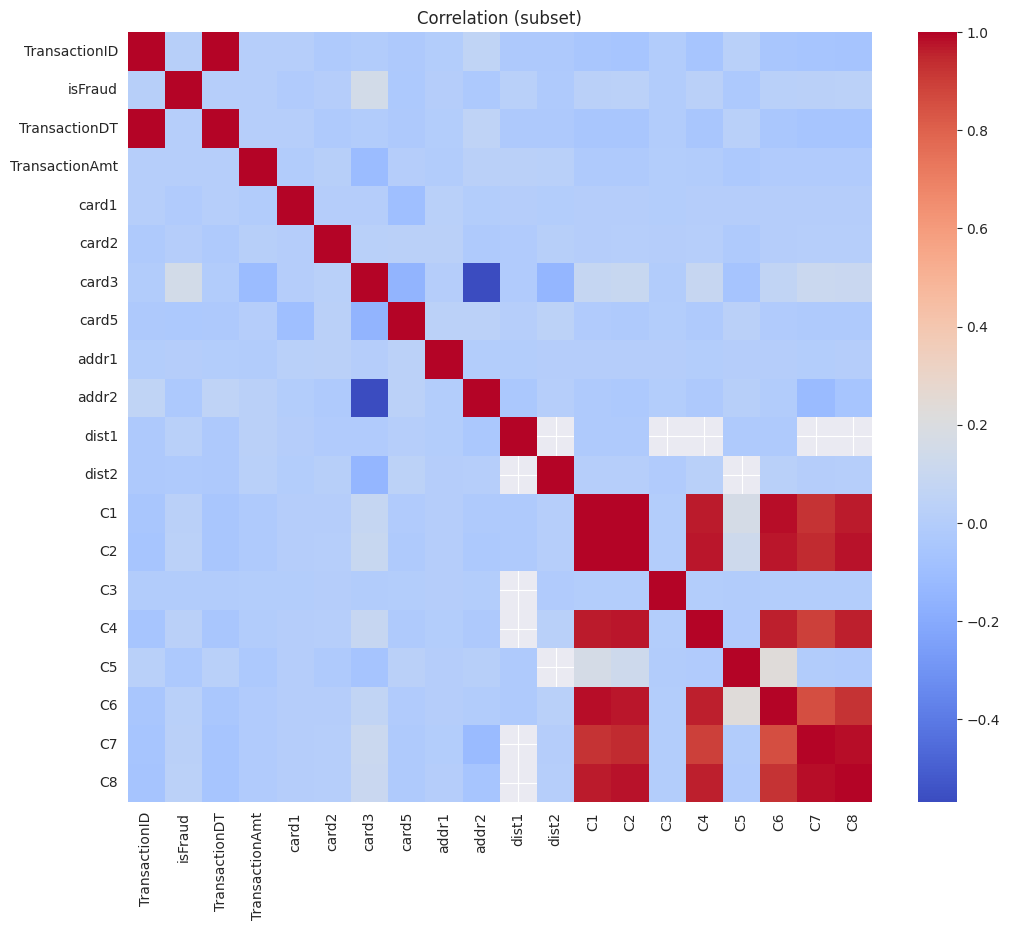

In [12]:
corr = train.select_dtypes(include="number").corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr.iloc[:20, :20], cmap="coolwarm")
plt.title("Correlation (subset)")
plt.show()

In [19]:
import pandas as pd

def analyze_categorical_signal(df, col, target="isFraud", min_count=50):
    """
    Checks whether a categorical feature has predictive signal for fraud.
    """

    print(f"\n{'='*60}")
    print(f"Analyzing: {col}")
    print(f"{'='*60}")

    # 1. Basic stats
    value_counts = df[col].value_counts(dropna=False)
    print(f"Unique values: {df[col].nunique(dropna=False)}")
    print(f"Top category frequency: {value_counts.iloc[0] / len(df):.4f}")

    # 2. Fraud rate per category
    grouped = df.groupby(col)[target].agg(["count", "mean"]).reset_index()
    grouped.columns = [col, "count", "fraud_rate"]

    # filter small samples (important!)
    grouped_filtered = grouped[grouped["count"] >= min_count]

    print(f"\nCategories with at least {min_count} samples: {len(grouped_filtered)}")

    if len(grouped_filtered) == 0:
        print("Not enough data for reliable signal check.")
        return

    # 3. Show most suspicious categories
    top_fraud = grouped_filtered.sort_values("fraud_rate", ascending=False).head(10)

    print("\nTop fraud-rate categories:")
    print(top_fraud)

    # 4. Show most common categories
    top_common = grouped.sort_values("count", ascending=False).head(10)

    print("\nMost frequent categories:")
    print(top_common)

    # 5. Quick signal judgment
    fraud_variation = grouped_filtered["fraud_rate"].std()

    print(f"\nFraud rate std (signal strength): {fraud_variation:.6f}")

    if fraud_variation > 0.01:
        print("👉 Potential predictive signal detected")
    else:
        print("👉 Weak or no predictive signal")

# ----------------------------
# RUN ON YOUR FEATURES
# ----------------------------

rare_features = ["id_23", "id_27", "id_24", "id_25"]  # extend if needed

for col in rare_features:
    if col in train.columns:
        analyze_categorical_signal(train, col)


Analyzing: id_23
Unique values: 4
Top category frequency: 0.9912

Categories with at least 50 samples: 3

Top fraud-rate categories:
                  id_23  count  fraud_rate
0    IP_PROXY:ANONYMOUS   1071    0.137255
2  IP_PROXY:TRANSPARENT   3489    0.070221
1       IP_PROXY:HIDDEN    609    0.055829

Most frequent categories:
                  id_23  count  fraud_rate
2  IP_PROXY:TRANSPARENT   3489    0.070221
0    IP_PROXY:ANONYMOUS   1071    0.137255
1       IP_PROXY:HIDDEN    609    0.055829

Fraud rate std (signal strength): 0.043457
👉 Potential predictive signal detected

Analyzing: id_27
Unique values: 3
Top category frequency: 0.9912

Categories with at least 50 samples: 1

Top fraud-rate categories:
   id_27  count  fraud_rate
0  Found   5155    0.082638

Most frequent categories:
      id_27  count  fraud_rate
0     Found   5155    0.082638
1  NotFound     14    0.000000

Fraud rate std (signal strength): nan
👉 Weak or no predictive signal

Analyzing: id_24
Unique values:

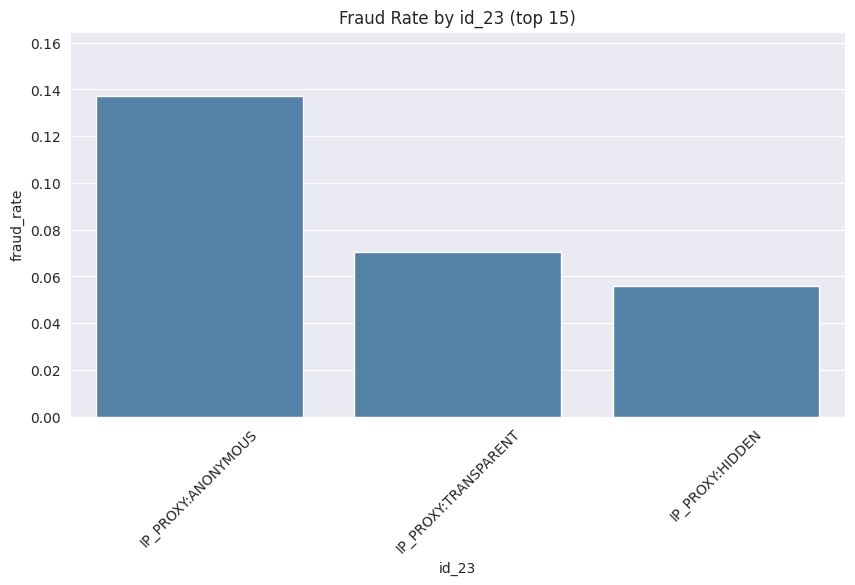

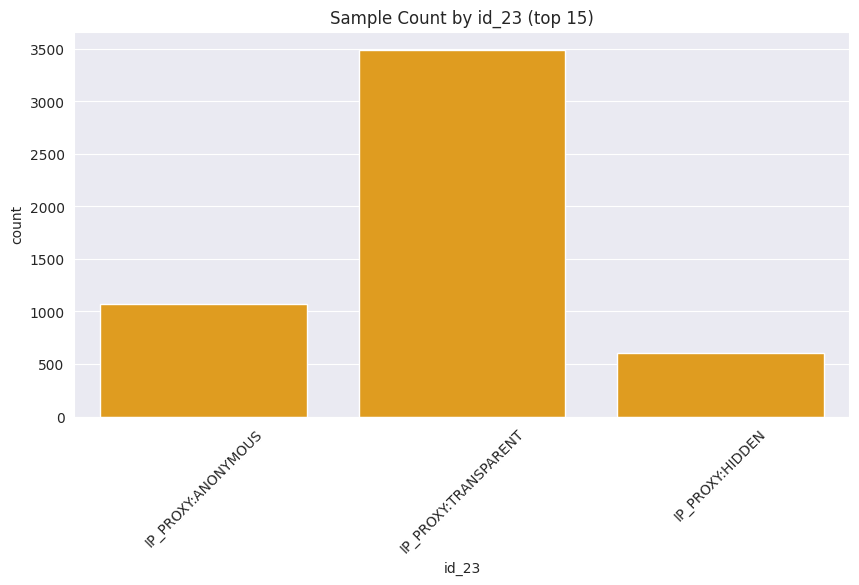

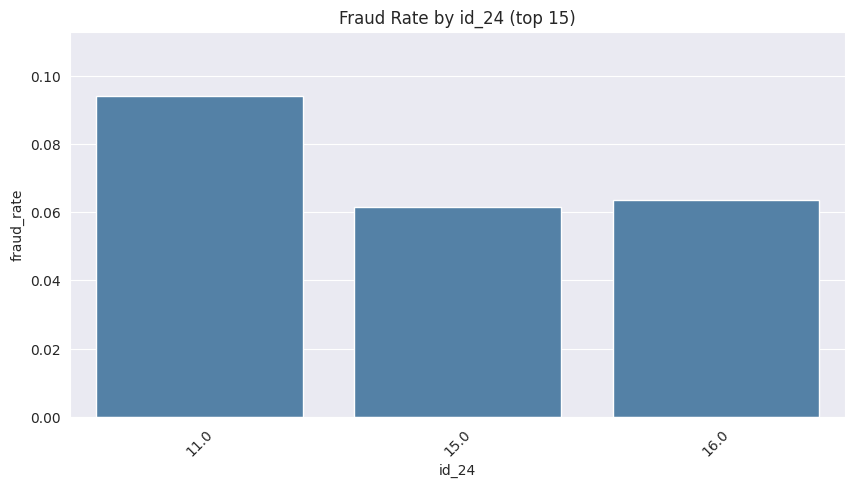

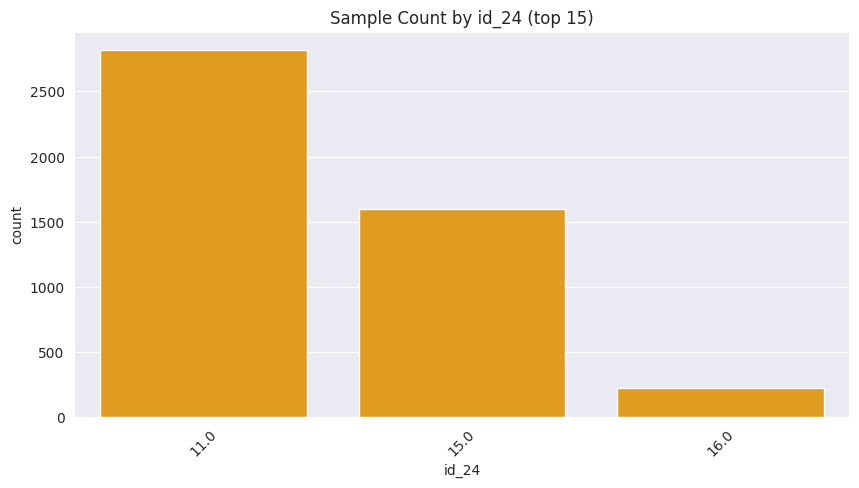

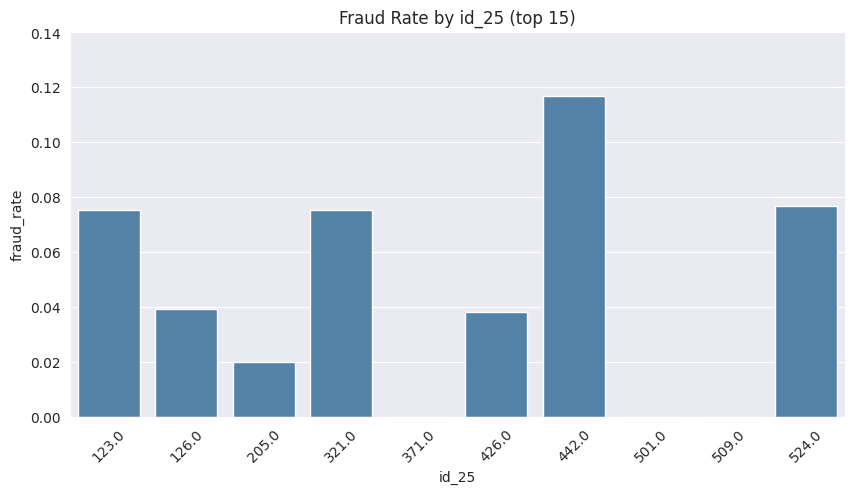

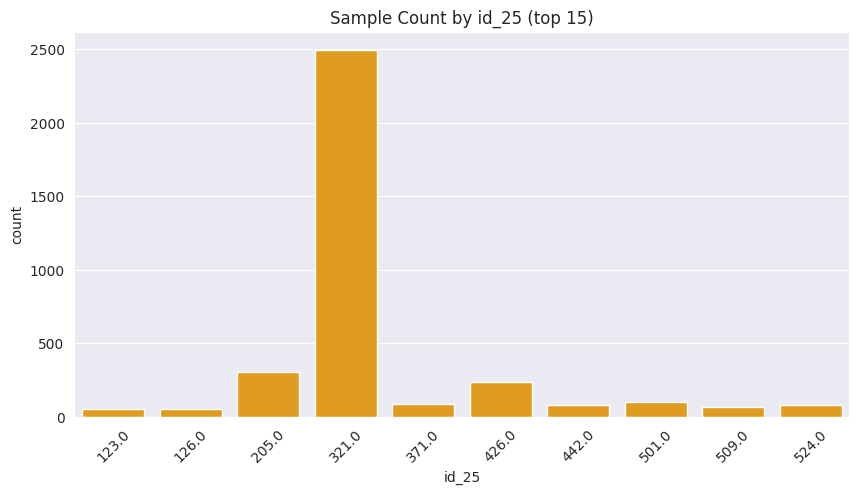

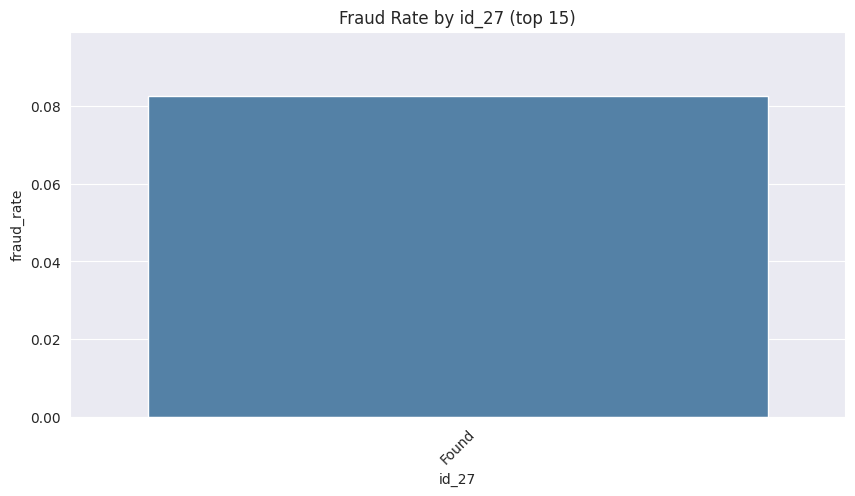

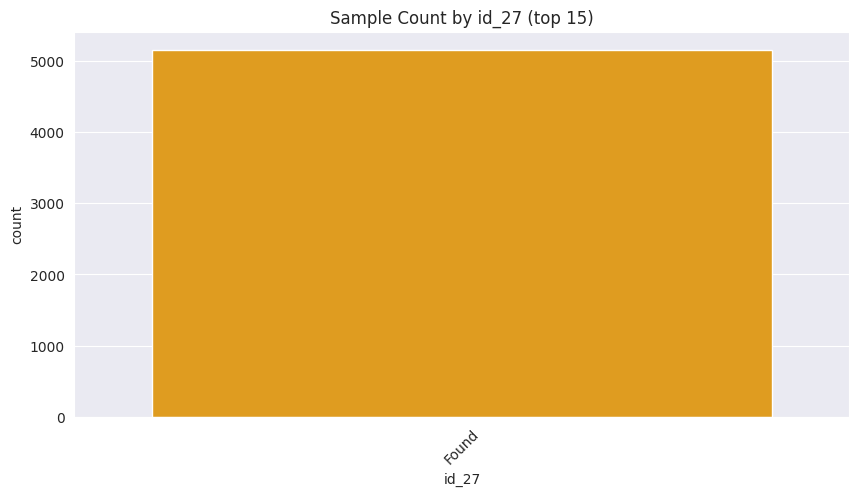

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cat_fraud(df, col, target="isFraud", min_count=50, top_n=15):
    """
    Visualizes fraud rate per category + sample counts.
    """

    # aggregate
    agg = df.groupby(col)[target].agg(["count", "mean"]).reset_index()
    agg.columns = [col, "count", "fraud_rate"]

    # filter small samples (important for stability)
    agg_filtered = agg[agg["count"] >= min_count]

    if agg_filtered.empty:
        print(f"No categories with >= {min_count} samples for {col}")
        return

    # sort by fraud rate
    agg_sorted = agg_filtered.sort_values("fraud_rate", ascending=False)

    # take top categories
    plot_data = agg_sorted.head(top_n)

    plt.figure(figsize=(10,5))
    sns.barplot(data=plot_data, x=col, y="fraud_rate", color="steelblue")

    plt.title(f"Fraud Rate by {col} (top {top_n})")
    plt.xticks(rotation=45)
    plt.ylim(0, max(plot_data["fraud_rate"]) * 1.2)

    plt.show()

    # second plot: counts (to check reliability)
    plt.figure(figsize=(10,5))
    sns.barplot(data=plot_data, x=col, y="count", color="orange")

    plt.title(f"Sample Count by {col} (top {top_n})")
    plt.xticks(rotation=45)

    plt.show()

# -------------------------
# RUN IT
# -------------------------

cols_to_plot = ["id_23", "id_24", "id_25", "id_27"]

for c in cols_to_plot:
    if c in train.columns:
        plot_cat_fraud(train, c)